In [1]:
"""
Question 1 — Bond Structure and Static Replication
===================================================
UniCredit Variable Rate Bond 2034 (ISIN IT0005599110)

Produces:
  1. Console: key bond metrics
  2. Console: replication identity check (numerical verification)
  3. Console: static replication table (A)–(D)
  4. Chart:   piecewise-linear coupon payoff R(L) vs 3m EURIBOR

Bond parameters
---------------
Participation: 160%
Cap            : 5.45% p.a.
Floor          : 0.00% p.a.
Reference      : 3m EURIBOR (EUR003M)
Day count      : 30/360  ->  alpha = 0.25 per quarter
Nominal        : EUR 1,000
Maturity       : 12 June 2034  (40 quarterly periods)
"""

'\nQuestion 1 — Bond Structure and Static Replication\n===================================================\nUniCredit Variable Rate Bond 2034 (ISIN IT0005599110)\n\nProduces:\n  1. Console: key bond metrics\n  2. Console: replication identity check (numerical verification)\n  3. Console: static replication table (A)–(D)\n  4. Chart:   piecewise-linear coupon payoff R(L) vs 3m EURIBOR\n\nBond parameters\n---------------\nParticipation: 160%\nCap            : 5.45% p.a.\nFloor          : 0.00% p.a.\nReference      : 3m EURIBOR (EUR003M)\nDay count      : 30/360  ->  alpha = 0.25 per quarter\nNominal        : EUR 1,000\nMaturity       : 12 June 2034  (40 quarterly periods)\n'

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Bond parameters ──────────────────────────────────────────────────────────
PARTICIPATION = 1.60        # 160%
CAP_RATE      = 0.0545      # 5.45% p.a.
FLOOR_RATE    = 0.0000      # 0.00% p.a.
NOMINAL       = 1_000       # EUR
ALPHA         = 0.25        # 30/360 quarterly accrual fraction
N_PERIODS     = 40          # total coupon periods

# Derived
L_STAR    = CAP_RATE / PARTICIPATION   # cap breakeven = 3.40625%
L_CURRENT = 0.02029                    # 3m EURIBOR as of Nov 2025 (period-6 fixing)

In [3]:
# ── 1. Coupon formula ─────────────────────────────────────────────────────────
def coupon_rate(L):
    """
    Annualised structured coupon rate as a function of EURIBOR fixing L.

    R(L) = min(cap, max(floor, participation * L))

    Parameters
    ----------
    L : float or np.ndarray
        3m EURIBOR fixing (decimal, e.g. 0.02 for 2%)

    Returns
    -------
    R : same type as L, annualised coupon rate (decimal)
    """
    return np.minimum(CAP_RATE, np.maximum(FLOOR_RATE, PARTICIPATION * L))

def coupon_amount(L):
    """Quarterly coupon cashflow = nominal * R(L) * alpha."""
    return NOMINAL * coupon_rate(L) * ALPHA

In [4]:
# ── 2. Key metrics ────────────────────────────────────────────────────────────
def print_key_metrics():
    sep = "-" * 68
    print(f"\n{sep}")
    print("  Key structured bond metrics")
    print(sep)
    rows = [
        ("Participation factor",          f"{PARTICIPATION:.0%}"),
        ("Cap rate (p.a.)",               f"{CAP_RATE:.2%}"),
        ("Floor rate (p.a.)",             f"{FLOOR_RATE:.2%}"),
        ("Cap breakeven L*",              f"{L_STAR:.5%}  =  {CAP_RATE:.2%} / {PARTICIPATION:.0%}"),
        ("Day count / alpha",             f"30/360  ->  {ALPHA:.2f} per quarter"),
        ("Number of coupon periods",      f"{N_PERIODS}"),
        ("Max quarterly coupon",
         f"EUR {coupon_amount(L_STAR + 0.01):,.3f}"
         f"  =  {NOMINAL} x {CAP_RATE:.2%} x {ALPHA}"),
        ("Current 3m EURIBOR (Nov 2025)", f"{L_CURRENT:.3%}"),
        ("Current coupon rate",
         f"{coupon_rate(L_CURRENT):.4%}"
         f"  =  {PARTICIPATION} x {L_CURRENT:.3%}"),
        ("Current quarterly coupon",      f"EUR {coupon_amount(L_CURRENT):,.3f}"),
    ]
    for label, value in rows:
        print(f"  {label:<38} {value}")
    print(sep)

In [5]:
# ── 3. Replication identity check ─────────────────────────────────────────────
def replication_check():
    """
    Verify numerically that the collar decomposition holds:

        R(L) = 1.6*L  +  1.6*max(-L, 0)  -  1.6*max(L - L*, 0)

    at representative EURIBOR levels covering all three regimes.
    """
    sep = "-" * 68
    print(f"\n{sep}")
    print("  Replication identity check")
    print(f"  R(L) = 1.6*L  +  1.6*max(-L,0)  -  1.6*max(L-L*,0)")
    print(sep)
    print(f"  {'L':>9}  {'Regime':<18}  {'Direct':>12}  {'Replicated':>12}  {'OK':>4}")
    print(sep)

    test_cases = [
        (-0.010, "floor binding"),
        ( 0.000, "floor boundary"),
        ( 0.010, "linear zone"),
        ( L_STAR, "cap boundary"),
        ( 0.040, "cap binding"),
        ( 0.060, "cap binding"),
    ]
    for L, regime in test_cases:
        direct     = coupon_rate(L)
        replicated = (PARTICIPATION * L
                      + PARTICIPATION * max(-L, 0.0)
                      - PARTICIPATION * max(L - L_STAR, 0.0))
        ok = "OK" if abs(direct - replicated) < 1e-12 else "FAIL"
        print(f"  {L:>9.3%}  {regime:<18}  {direct:>12.6%}  {replicated:>12.6%}  {ok:>4}")
    print(sep)

In [6]:
# ── 4. Replication table ──────────────────────────────────────────────────────
REPLICATION_ROWS = [
    ("(A)", "Zero-coupon bond",
     "Par redemption at T_40",            "Long"),
    ("(B)", "Leveraged FRN  (x1.6)",
     "160% of 3m EURIBOR each quarter",   "Long"),
    ("(C)", "Strip of 40 floorlets at 0%",
     "Prevents coupons going negative",   "Long x1.6"),
    ("(D)", "Strip of 40 caplets at 3.406%",
     "Caps coupon at 5.45% p.a.",         "Short x1.6"),
]

def print_replication_table():
    sep = "-" * 80
    print(f"\n{sep}")
    print("  Static replication -- UniCredit Variable Rate Bond 2034")
    print(sep)
    print(f"  {'':3}  {'Instrument':<30}  {'Role':<34}  {'Position'}")
    print(sep)
    for tag, instr, role, pos in REPLICATION_ROWS:
        print(f"  {tag:3}  {instr:<30}  {role:<34}  {pos}")
    print(sep)
    print()
    print("  Bond value  =  (A) + (B) + (C) - (D)")
    print("              =  ZCB  +  Leveraged FRN")
    print("                 +  Long floorlet strip  -  Short caplet strip")
    print(sep)

  Q1 -- Bond Structure and Static Replication
  UniCredit Variable Rate Bond 2034  (ISIN IT0005599110)

--------------------------------------------------------------------
  Key structured bond metrics
--------------------------------------------------------------------
  Participation factor                   160%
  Cap rate (p.a.)                        5.45%
  Floor rate (p.a.)                      0.00%
  Cap breakeven L*                       3.40625%  =  5.45% / 160%
  Day count / alpha                      30/360  ->  0.25 per quarter
  Number of coupon periods               40
  Max quarterly coupon                   EUR 13.625  =  1000 x 5.45% x 0.25
  Current 3m EURIBOR (Nov 2025)          2.029%
  Current coupon rate                    3.2464%  =  1.6 x 2.029%
  Current quarterly coupon               EUR 8.116
--------------------------------------------------------------------

--------------------------------------------------------------------
  Replication identity chec

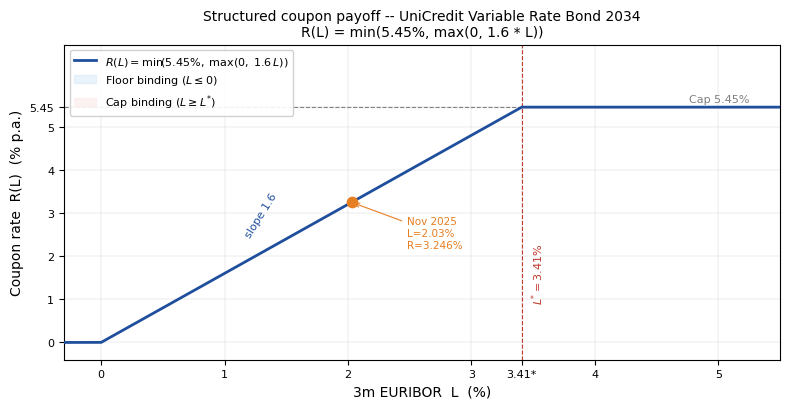

In [7]:
# ── 5. Coupon payoff chart ────────────────────────────────────────────────────
def plot_coupon_payoff():
    fig, ax = plt.subplots(figsize=(8, 4.2))

    L = np.linspace(-0.005, 0.055, 2000)
    R = coupon_rate(L)

    # Main payoff line
    ax.plot(L * 100, R * 100,
            color="#1f4e9c", linewidth=2.0, zorder=4,
            label=r"$R(L)=\min\!\left(5.45\%,\;\max(0,\;1.6\,L)\right)$")

    # Cap reference line
    ax.axhline(CAP_RATE * 100, color="gray",
               linewidth=0.8, linestyle="--", zorder=2)
    ax.text(5.25, CAP_RATE * 100 + 0.13, "Cap 5.45%",
            fontsize=8, color="gray", ha="right")

    # L* breakeven vertical
    ax.axvline(L_STAR * 100, color="#c0392b",
               linewidth=0.8, linestyle="--", zorder=2)
    ax.text(L_STAR * 100 + 0.06, 1.6,
            f"$L^{{*}}={L_STAR*100:.2f}\\%$",
            fontsize=8, color="#c0392b", rotation=90, va="center")

    # Floor active shading (L <= 0)
    ax.fill_between(L * 100, 0, R * 100,
                    where=(L <= 0),
                    color="#d6eaf8", alpha=0.55, zorder=1,
                    label="Floor binding ($L \\leq 0$)")

    # Cap active shading (L >= L*)
    ax.fill_between(L * 100, R * 100, CAP_RATE * 100,
                    where=(L >= L_STAR),
                    color="#fde8e8", alpha=0.55, zorder=1,
                    label="Cap binding ($L \\geq L^{*}$)")

    # Slope annotation in linear zone
    ax.text(1.15, 2.45, "slope 1.6", fontsize=8,
            color="#1f4e9c", rotation=58)

    # Current market point Nov 2025
    R_now = coupon_rate(L_CURRENT)
    ax.scatter([L_CURRENT * 100], [R_now * 100],
               color="#e67e22", s=55, zorder=5)
    ax.annotate(
        f"Nov 2025\nL={L_CURRENT*100:.2f}%\nR={R_now*100:.3f}%",
        xy=(L_CURRENT * 100, R_now * 100),
        xytext=(L_CURRENT * 100 + 0.45, R_now * 100 - 1.05),
        fontsize=7.5, color="#e67e22",
        arrowprops=dict(arrowstyle="->", color="#e67e22", lw=0.8),
    )

    # Axes formatting
    ax.set_xlim(-0.3, 5.5)
    ax.set_ylim(-0.4, 6.9)
    ax.set_xlabel("3m EURIBOR  L  (%)", fontsize=10)
    ax.set_ylabel("Coupon rate  R(L)  (% p.a.)", fontsize=10)
    ax.set_title(
        "Structured coupon payoff -- UniCredit Variable Rate Bond 2034\n"
        "R(L) = min(5.45%, max(0, 1.6 * L))",
        fontsize=10,
    )

    xtick_vals   = [0, 1, 2, 3, L_STAR * 100, 4, 5]
    xtick_labels = ["0", "1", "2", "3", f"{L_STAR*100:.2f}*", "4", "5"]
    ax.set_xticks(xtick_vals)
    ax.set_xticklabels(xtick_labels, fontsize=8)
    ax.set_yticks([0, 1, 2, 3, 4, 5, CAP_RATE * 100])
    ax.set_yticklabels(["0", "1", "2", "3", "4", "5", "5.45"], fontsize=8)

    ax.grid(True, linewidth=0.3, color="lightgray")
    ax.legend(fontsize=8, loc="upper left", framealpha=0.9)

    fig.tight_layout()
    plt.show()


# ── Run all sections ──────────────────────────────────────────────────────────
print("=" * 80)
print("  Q1 -- Bond Structure and Static Replication")
print("  UniCredit Variable Rate Bond 2034  (ISIN IT0005599110)")
print("=" * 80)

print_key_metrics()
replication_check()
print_replication_table()
plot_coupon_payoff()